# PixelDrop — Pandas Project
## Notebook 03: Product Analysis

**Goal:** Deep dive into product performance — revenue, units, return rates, discounts, margins.

**Business questions answered:**
1. What is the revenue breakdown by category?
2. Top 5 products by revenue vs units sold
3. Which product has the highest return rate?
4. Do higher discounts lead to more units sold?
5. Which category has the best gross margin?
6. Average discount per category

## Step 1: Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
BRAND_COLOR = '#1B1F3B'
ACCENT_COLOR = '#E63946'
COLORS = ['#1B1F3B', '#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

PATH = r'C:\Users\\איתי\Desktop\claude\data\clean\\'

order_summary = pd.read_csv(PATH + 'order_summary.csv', parse_dates=['order_date'])
products      = pd.read_csv(PATH + 'products_clean.csv')
returns       = pd.read_csv(PATH + 'returns_clean.csv')

print(f'order_summary: {order_summary.shape}')
print(f'products:      {products.shape}')
print(f'returns:       {returns.shape}')

order_summary: (24360, 33)
products:      (15, 7)
returns:       (1500, 7)


## Q1: Revenue by Category

In [2]:
revenue_by_cat = (
    order_summary
    .groupby('category')['line_total']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_cat.columns = ['category', 'total_revenue']
revenue_by_cat['pct_of_total'] = (revenue_by_cat['total_revenue'] / revenue_by_cat['total_revenue'].sum() * 100).round(1)

print('Revenue by Category:')
print(revenue_by_cat.to_string(index=False))

Revenue by Category:
   category  total_revenue  pct_of_total
   Sneakers     1697650.78          36.8
    Hoodies     1404075.61          30.4
    Bottoms      696489.53          15.1
   T-Shirts      345496.58           7.5
       Caps      306372.13           6.6
Accessories      162308.11           3.5


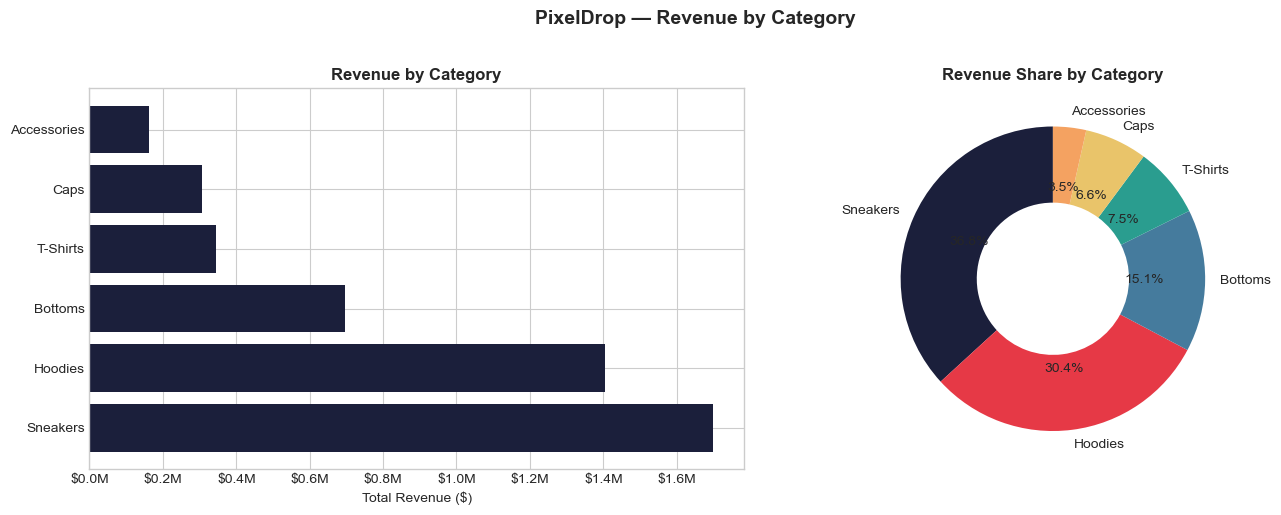

In [3]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].barh(revenue_by_cat['category'], revenue_by_cat['total_revenue'], color=BRAND_COLOR)
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    revenue_by_cat['total_revenue'],
    labels=revenue_by_cat['category'],
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Revenue Share by Category', fontweight='bold')

plt.suptitle('PixelDrop — Revenue by Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs(os.path.join(PATH, 'charts'), exist_ok=True)
plt.savefig(os.path.join(PATH, 'charts', '01_revenue_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

## Q2: Top 5 Products — Revenue vs Units Sold

In [4]:
product_perf = (
    order_summary
    .groupby('product_name')
    .agg(
        total_revenue=('line_total', 'sum'),
        units_sold=('quantity', 'sum'),
        avg_order_value=('line_total', 'mean')
    )
    .round(2)
    .reset_index()
)

top5_revenue = product_perf.nlargest(5, 'total_revenue')
top5_units   = product_perf.nlargest(5, 'units_sold')

print('Top 5 by Revenue:')
print(top5_revenue[['product_name', 'total_revenue']].to_string(index=False))
print('\nTop 5 by Units Sold:')
print(top5_units[['product_name', 'units_sold']].to_string(index=False))

Top 5 by Revenue:
        product_name  total_revenue
      High Top Force      796899.47
       Puffer Jacket      702192.69
Retro Runner Sneaker      680758.68
         Cargo Pants      414728.93
          Zip Hoodie      364101.81

Top 5 by Units Sold:
        product_name  units_sold
Retro Runner Sneaker      4233.0
          Air Hoodie      4224.0
       Puffer Jacket      4149.0
    Graphic Tee Vol2      4130.0
           Slide Pro      4124.0


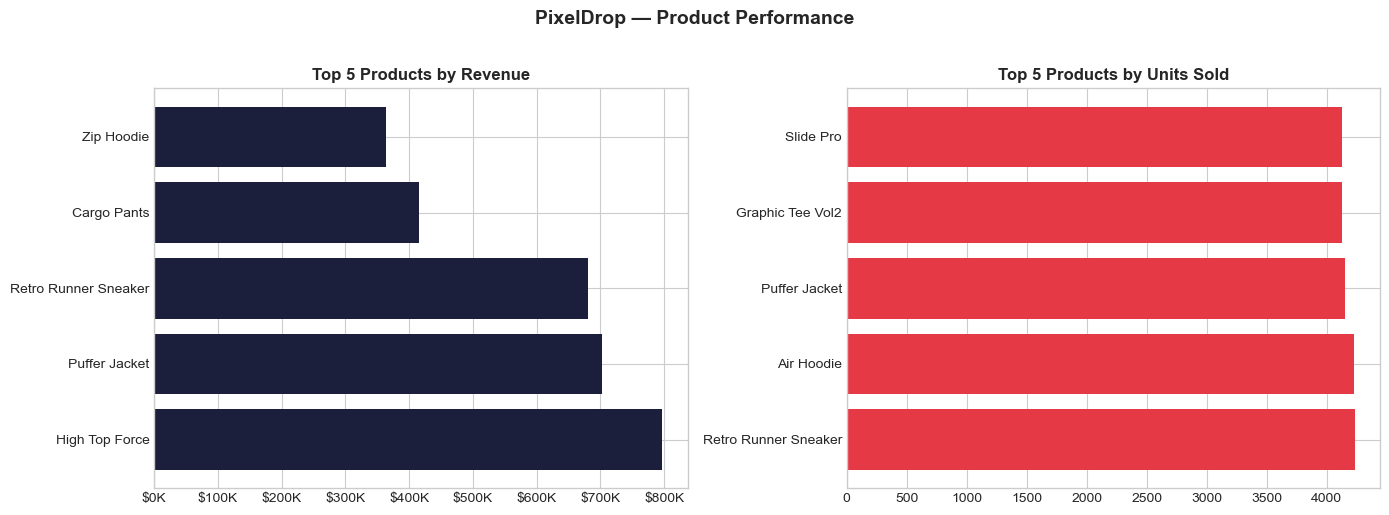


Insight: Revenue top 5 and Units top 5 are COMPLETELY different lists!
Only Retro Runner Sneaker appears in both — the sweet spot product.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 5 by Revenue
axes[0].barh(top5_revenue['product_name'], top5_revenue['total_revenue'], color=BRAND_COLOR)
axes[0].set_title('Top 5 Products by Revenue', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Top 5 by Units
axes[1].barh(top5_units['product_name'], top5_units['units_sold'], color=ACCENT_COLOR)
axes[1].set_title('Top 5 Products by Units Sold', fontweight='bold')

plt.suptitle('PixelDrop — Product Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PATH + 'charts/02_top5_products.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight: Revenue top 5 and Units top 5 are COMPLETELY different lists!')
print('Only Retro Runner Sneaker appears in both — the sweet spot product.')

## Q3: Return Rate by Product

In [6]:
# Orders per product
orders_per_product = (
    order_summary
    .groupby('product_name')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

# Returns per product
returns_per_product = (
    returns
    .groupby('product_id')['return_id']
    .count()
    .reset_index()
    .rename(columns={'return_id': 'total_returns'})
)

# Merge products with returns
product_returns = products[['product_id', 'product_name']].merge(
    returns_per_product, on='product_id', how='left'
)
product_returns = product_returns.merge(
    orders_per_product, on='product_name', how='left'
)
product_returns['total_returns'] = product_returns['total_returns'].fillna(0)
product_returns['return_rate_pct'] = (
    product_returns['total_returns'] / product_returns['total_orders'] * 100
).round(2)
product_returns = product_returns.sort_values('return_rate_pct', ascending=False)

print('Return Rate by Product:')
print(product_returns[['product_name', 'total_orders', 'total_returns', 'return_rate_pct']].to_string(index=False))

Return Rate by Product:
        product_name  total_orders  total_returns  return_rate_pct
          Air Hoodie          1709            125             7.31
           Slide Pro          1660            112             6.75
      High Top Force          1625            107             6.58
    Graphic Tee Vol2          1638            106             6.47
Retro Runner Sneaker          1674            107             6.39
          Bucket Hat          1605            102             6.36
         Canvas Tote          1650            104             6.30
      Chain Necklace          1610            101             6.27
            Drop Tee          1531             92             6.01
         Jogger Slim          1561             92             5.89
         Classic Tee          1608             94             5.85
         Cargo Pants          1590             93             5.85
          Zip Hoodie          1648             93             5.64
   PixelCap Snapback          1587    

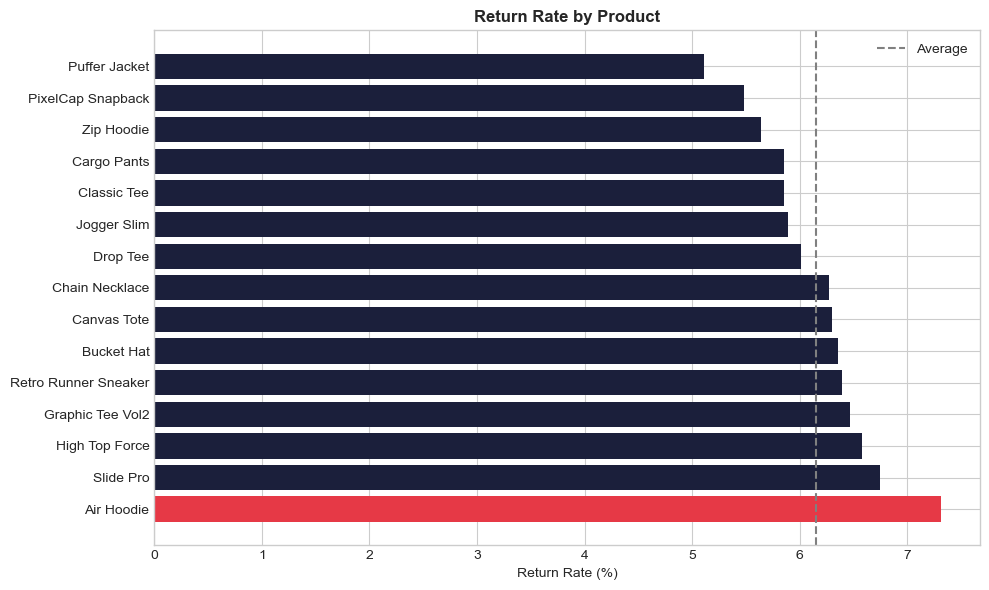

In [7]:
plt.figure(figsize=(10, 6))
colors = [ACCENT_COLOR if x == product_returns['return_rate_pct'].max() else BRAND_COLOR
          for x in product_returns['return_rate_pct']]
plt.barh(product_returns['product_name'], product_returns['return_rate_pct'], color=colors)
plt.xlabel('Return Rate (%)')
plt.title('Return Rate by Product', fontweight='bold')
plt.axvline(x=product_returns['return_rate_pct'].mean(), color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.savefig(PATH + 'charts/03_return_rate_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## Q4: Do Higher Discounts Lead to More Units Sold?

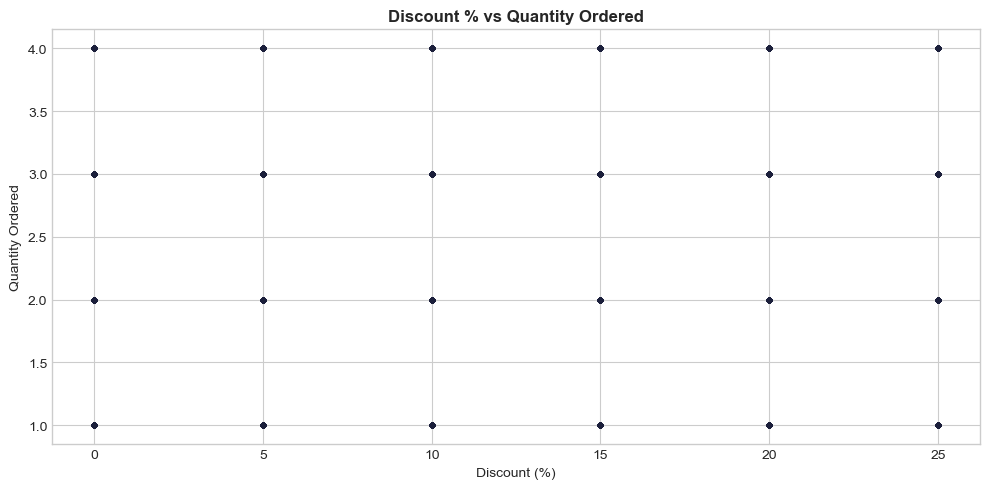

Correlation between discount and quantity: -0.003
Insight: Low/no correlation — discounts do not significantly drive more units sold!


In [8]:
discount_analysis = (
    order_summary
    .groupby('discount_%')
    .agg(
        avg_units=('quantity', 'mean'),
        order_count=('order_id', 'count')
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.scatter(
    order_summary['discount_%'],
    order_summary['quantity'],
    alpha=0.1,
    color=BRAND_COLOR,
    s=10
)
plt.xlabel('Discount (%)')
plt.ylabel('Quantity Ordered')
plt.title('Discount % vs Quantity Ordered', fontweight='bold')
plt.tight_layout()
plt.savefig(PATH + 'charts/04_discount_vs_quantity.png', dpi=150, bbox_inches='tight')
plt.show()

corr = order_summary[['discount_%', 'quantity']].corr().iloc[0,1]
print(f'Correlation between discount and quantity: {corr:.3f}')
print('Insight: Low/no correlation — discounts do not significantly drive more units sold!')

## Q5: Gross Margin by Category
Gross margin = (Revenue - Cost) / Revenue × 100

In [9]:
margin_analysis = (
    order_summary
    .groupby('category')
    .agg(
        total_revenue=('line_total', 'sum'),
        total_cost=('cost_price', lambda x: (x * order_summary.loc[x.index, 'quantity']).sum())
    )
    .reset_index()
)
margin_analysis['gross_margin_pct'] = (
    (margin_analysis['total_revenue'] - margin_analysis['total_cost']) /
    margin_analysis['total_revenue'] * 100
).round(1)
margin_analysis = margin_analysis.sort_values('gross_margin_pct', ascending=False)

print('Gross Margin by Category:')
print(margin_analysis[['category', 'total_revenue', 'gross_margin_pct']].to_string(index=False))

Gross Margin by Category:
   category  total_revenue  gross_margin_pct
Accessories      162308.11              65.0
   T-Shirts      345496.58              62.3
       Caps      306372.13              56.3
    Bottoms      696489.53              52.2
    Hoodies     1404075.61              50.5
   Sneakers     1697650.78              49.2


## Q6: Average Discount by Category

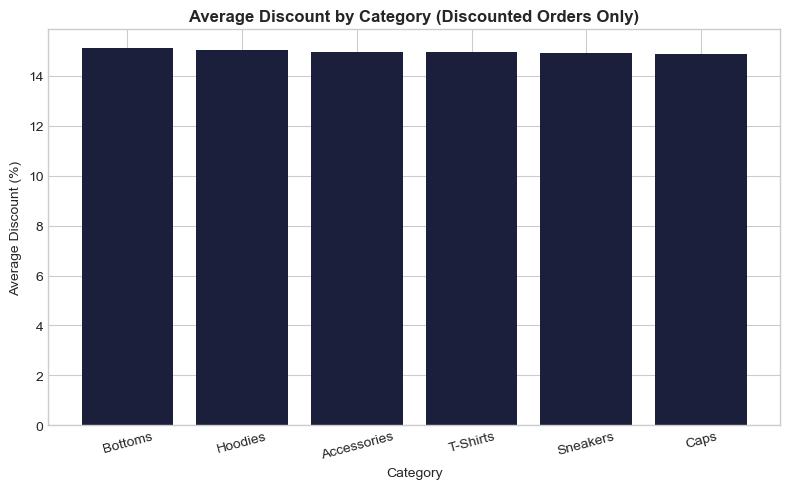

   category  avg_discount_pct
    Bottoms             15.11
    Hoodies             15.03
Accessories             14.98
   T-Shirts             14.98
   Sneakers             14.91
       Caps             14.88


In [10]:
avg_discount = (
    order_summary[order_summary['discount_%'] > 0]
    .groupby('category')['discount_%']
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
avg_discount.columns = ['category', 'avg_discount_pct']

plt.figure(figsize=(8, 5))
plt.bar(avg_discount['category'], avg_discount['avg_discount_pct'], color=BRAND_COLOR)
plt.xlabel('Category')
plt.ylabel('Average Discount (%)')
plt.title('Average Discount by Category (Discounted Orders Only)', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PATH + 'charts/05_avg_discount_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(avg_discount.to_string(index=False))

## Summary — Product Analysis Insights

| Finding | Detail |
|---------|--------|
| Top revenue category | Sneakers ($1.7M, 36% of total) |
| Top revenue product | High Top Force (~$800K) |
| Top volume product | Retro Runner Sneaker (most units sold) |
| Highest return rate | Air Hoodie (7.31%) — likely sizing issues |
| Discount effect | Low correlation (r ≈ 0) — discounts don't drive volume |
| Best margin category | Accessories (65% gross margin) |

> **Note:** Revenue figures reflect Pandas-cleaned data (~24,360 line items after deduplication and quality filtering). SQL total was $6.0M using a different cleaning scope.

**Next:** Notebook 04 — Customer Analysis!